# State-Space Models & The Kalman Filter

## What is a State-Space Model?

A **state-space model** represents a system where:
- **Observations** are noisy measurements of an underlying **state**
- The **state** evolves over time according to a dynamic process

## The Local Level Model

The simplest state-space model:

**Observation equation:**
$$y_t = \\alpha_t + \\varepsilon_t, \\quad \\varepsilon_t \\sim N(0, \\sigma_{\\varepsilon}^2)$$

**State equation:**
$$\\alpha_t = \\alpha_{t-1} + \\eta_t, \\quad \\eta_t \\sim N(0, \\sigma_{\\eta}^2)$$

| Component | Meaning |
|-----------|---------|
| $y_t$ | Noisy observation at time $t$ |
| $\\alpha_t$ | True (unobserved) state at time $t$ |
| $\\sigma_{\\varepsilon}$ | Observation noise |
| $\\sigma_{\\eta}$ | State evolution noise |

## The Kalman Filter

The Kalman Filter recursively computes:

1. **Prediction**: Forecast the state using the model
2. **Update**: Correct the forecast using the new observation
3. **Smoothing** (RTS): Re-estimate using all future data

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================
# Generate Synthetic State-Space Data
# ============================================

n = 200

sigma_eta_true = 0.15   # State noise
sigma_eps_true = 0.5    # Observation noise

# True states: random walk with level shift at t=100
alpha_true = np.zeros(n)
alpha_true[0] = 10.0
for t in range(1, n):
    alpha_true[t] = alpha_true[t-1] + np.random.normal(0, sigma_eta_true)
    if t == 100:
        alpha_true[t] += 2.0  # Structural break

# Noisy observations
y = alpha_true + np.random.normal(0, sigma_eps_true, n)
time = np.arange(n)

df = pd.DataFrame({'time': time, 'y': y, 'alpha_true': alpha_true})

print("Data generated!")
print(f"Observations: {n}")
print(f"True sigma_eta: {sigma_eta_true}")
print(f"True sigma_eps: {sigma_eps_true}")
print(df.head())


Data generated!
Observations: 200
True sigma_eta: 0.15
True sigma_eps: 0.5
   time          y  alpha_true
0     0   9.428515   10.000000
1     1  10.253401   10.074507
2     2  10.334160   10.053767
3     3  10.692446   10.150921
4     4  10.906276   10.379375


## Observations vs True State vs Estimates

This plot shows the raw data alongside:
- The **true state** (known only in simulation)
- The **filtered estimate** (uses data up to time $t$)
- The **smoothed estimate** (uses all data, via RTS backward pass)

**Key insight:** Smoothed estimates are closer to the true state because they use future information.


In [44]:
# ============================================
# Kalman Filter + RTS Smoother (from scratch)
# ============================================

def kalman_filter(y, sigma_eta, sigma_eps, a0=0, P0=1e6):
    n = len(y)
    a_pred = np.zeros(n)
    a_filt = np.zeros(n)
    P_pred = np.zeros(n)
    P_filt = np.zeros(n)
    v = np.zeros(n)
    F = np.zeros(n)
    K = np.zeros(n)

    a_pred[0] = a0
    P_pred[0] = P0

    for t in range(n):
        v[t] = y[t] - a_pred[t]
        F[t] = P_pred[t] + sigma_eps**2
        K[t] = P_pred[t] / F[t]
        a_filt[t] = a_pred[t] + K[t] * v[t]
        P_filt[t] = P_pred[t] * (1 - K[t])
        if t < n - 1:
            a_pred[t+1] = a_filt[t]
            P_pred[t+1] = P_filt[t] + sigma_eta**2

    return a_pred, a_filt, P_pred, P_filt, v, F, K


def kalman_smoother(a_filt, P_filt, P_pred, sigma_eta):
    n = len(a_filt)
    a_smooth = np.zeros(n)
    P_smooth = np.zeros(n)
    a_smooth[-1] = a_filt[-1]
    P_smooth[-1] = P_filt[-1]

    for t in range(n-2, -1, -1):
        J = P_filt[t] / P_pred[t+1]
        a_smooth[t] = a_filt[t] + J * (a_smooth[t+1] - a_filt[t])
        P_smooth[t] = P_filt[t] + J**2 * (P_smooth[t+1] - P_pred[t+1])

    return a_smooth, P_smooth


# Run with true parameters
a_pred, a_filt, P_pred, P_filt, v, F, K = kalman_filter(
    y, sigma_eta_true, sigma_eps_true, a0=alpha_true[0], P0=1.0
)
a_smooth, P_smooth = kalman_smoother(a_filt, P_filt, P_pred, sigma_eta_true)

print("Kalman Filter and Smoother completed!")


Kalman Filter and Smoother completed!


## State Estimates Comparison


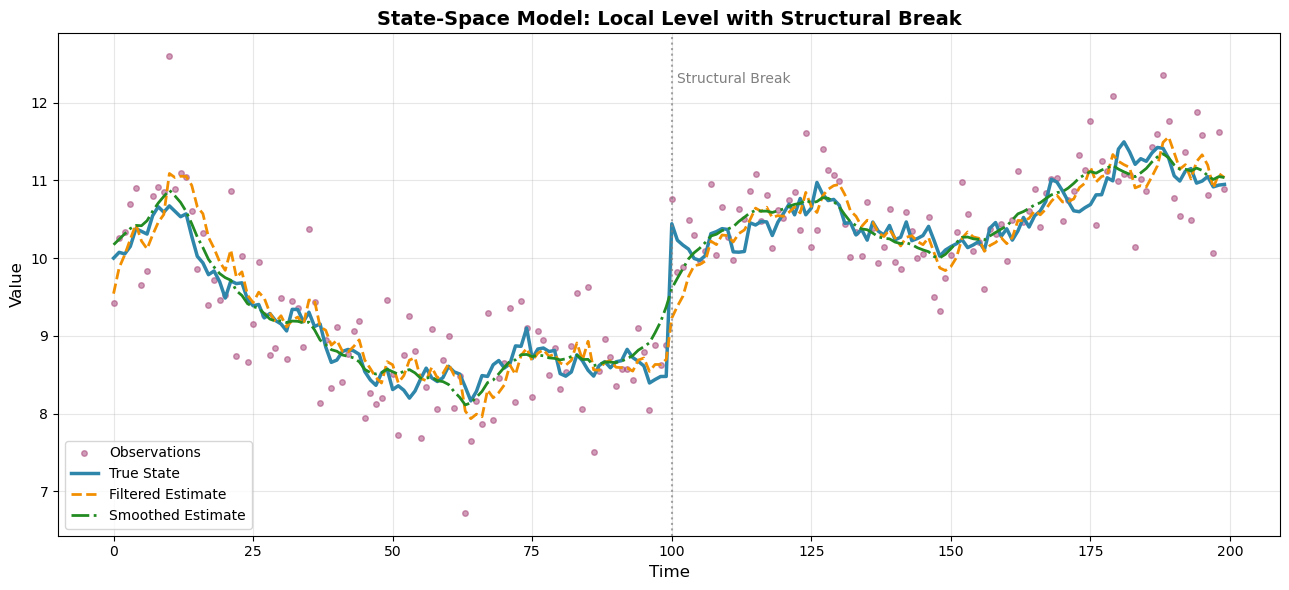

In [45]:
# ============================================
# Observations vs True State vs Estimates
# ============================================

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(time, y, 'o', color='#A23B72', markersize=4, alpha=0.5, label='Observations')
ax.plot(time, alpha_true, '-', color='#2E86AB', linewidth=2.5, label='True State')
ax.plot(time, a_filt, '--', color='#F18F01', linewidth=2, label='Filtered Estimate')
ax.plot(time, a_smooth, '-.', color='#228B22', linewidth=2, label='Smoothed Estimate')

ax.axvline(x=100, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(101, ax.get_ylim()[1] * 0.95, 'Structural Break', fontsize=10, color='gray')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('State-Space Model: Local Level with Structural Break', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Smoothed State with Confidence Intervals

The smoothed state estimate comes with an associated variance. We plot the 95% confidence band:

$$CI_t = \\hat{\\alpha}_t^{smooth} \\pm 1.96 \\times \\sqrt{P_t^{smooth}}$$

**What to look for:**
- Narrow bands = high confidence in the estimate
- Wide bands near the break = model uncertainty at structural changes
- True state inside the band = well-calibrated model

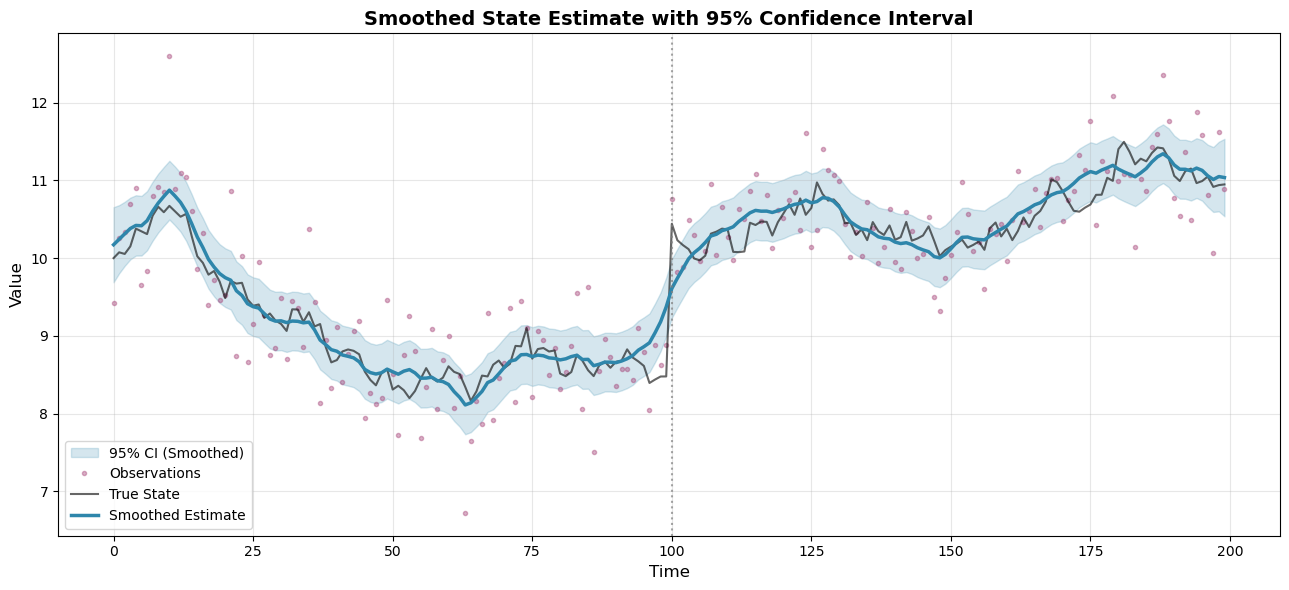

In [46]:
# ============================================
# Smoothed State with 95% Confidence Bands
# ============================================

smooth_se = np.sqrt(P_smooth)
ci_lower = a_smooth - 1.96 * smooth_se
ci_upper = a_smooth + 1.96 * smooth_se

fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(time, ci_lower, ci_upper, color='#2E86AB', alpha=0.2, label='95% CI (Smoothed)')
ax.plot(time, y, 'o', color='#A23B72', markersize=3, alpha=0.4, label='Observations')
ax.plot(time, alpha_true, '-', color='black', linewidth=1.5, alpha=0.6, label='True State')
ax.plot(time, a_smooth, '-', color='#2E86AB', linewidth=2.5, label='Smoothed Estimate')

ax.axvline(x=100, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Smoothed State Estimate with 95% Confidence Interval', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Innovation Diagnostics

**Innovations** (or prediction errors) are the key diagnostic for Kalman Filters:

$$v_t = y_t - \\hat{\\alpha}_t^{pred}$$

If the model is correct, standardized innovations should be:
- **White noise** (no autocorrelation)
- **Normally distributed** with mean 0 and variance 1
- **Homoscedastic** (constant variance over time)

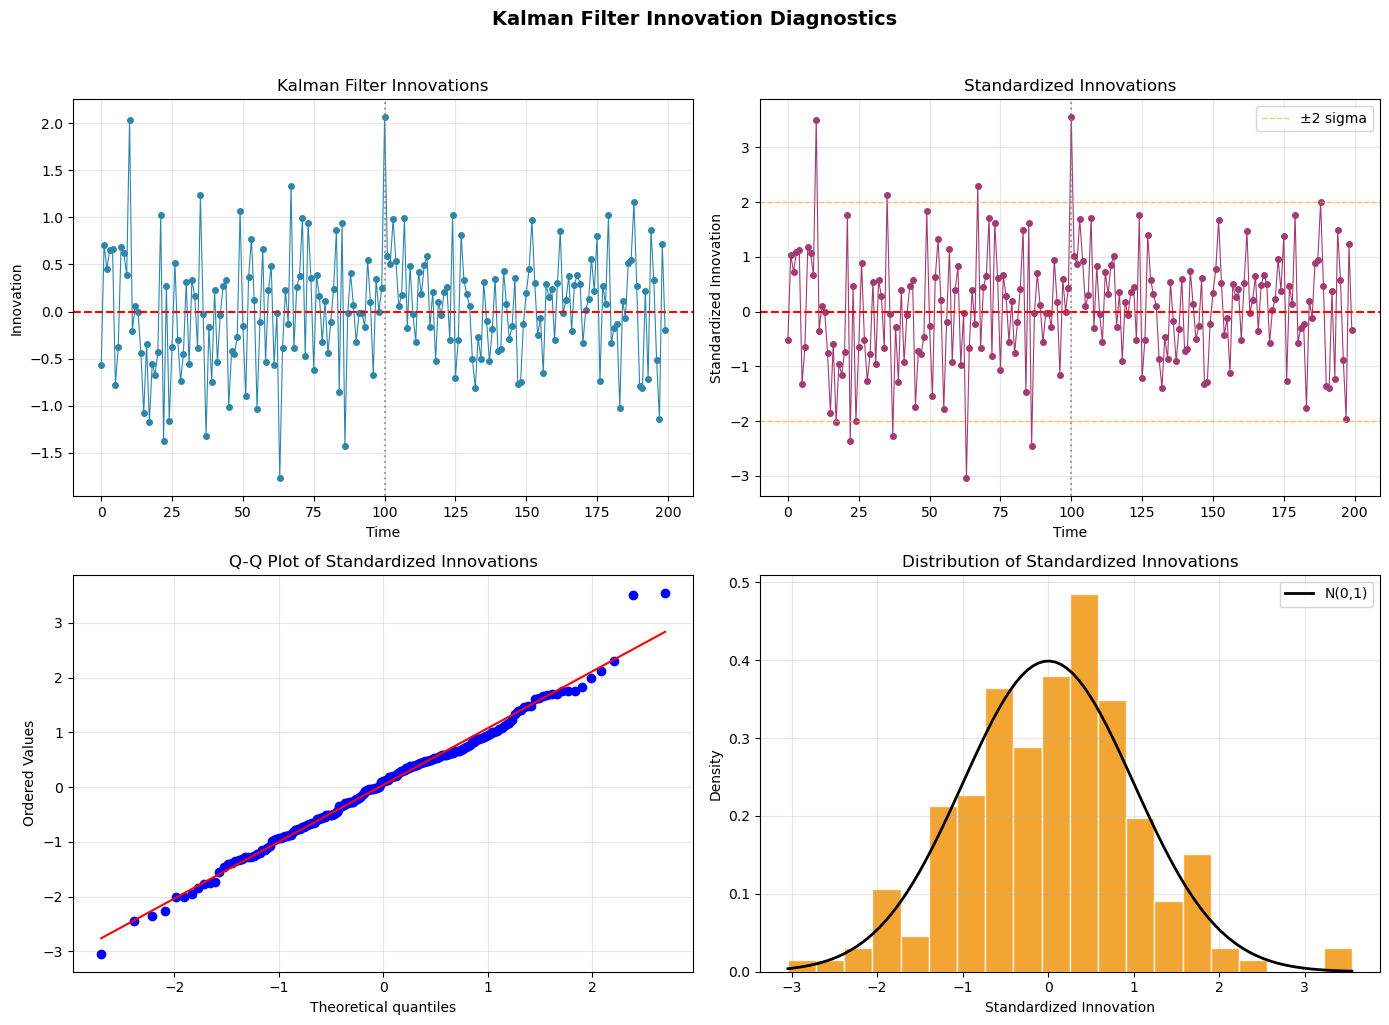

In [47]:
# ============================================
# Four-Panel Innovation Diagnostics
# ============================================

std_innovations = v / np.sqrt(F)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Innovations over time
ax = axes[0, 0]
ax.plot(time, v, 'o-', color='#2E86AB', markersize=4, linewidth=0.8)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=100, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Innovation')
ax.set_title('Kalman Filter Innovations')
ax.grid(True, alpha=0.3)

# 2. Standardized innovations
ax = axes[0, 1]
ax.plot(time, std_innovations, 'o-', color='#A23B72', markersize=4, linewidth=0.8)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.axhline(y=2, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='±2 sigma')
ax.axhline(y=-2, color='orange', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(x=100, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Standardized Innovation')
ax.set_title('Standardized Innovations')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Q-Q plot
ax = axes[1, 0]
stats.probplot(std_innovations, dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Standardized Innovations')
ax.grid(True, alpha=0.3)

# 4. Histogram
ax = axes[1, 1]
ax.hist(std_innovations, bins=20, color='#F18F01', edgecolor='white', alpha=0.8, density=True)
x_norm = np.linspace(std_innovations.min(), std_innovations.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, 0, 1), 'k-', linewidth=2, label='N(0,1)')
ax.set_xlabel('Standardized Innovation')
ax.set_ylabel('Density')
ax.set_title('Distribution of Standardized Innovations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Kalman Filter Innovation Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Kalman Gain & State Variance Evolution

**Kalman Gain** ($K_t$) determines how much weight to place on the new observation vs. the prediction:

$$K_t = \\frac{P_t^{pred}}{P_t^{pred} + \\sigma_{\\varepsilon}^2}$$

- $K_t \\approx 1$: Trust the observation (high observation noise relative to state noise)
- $K_t \\approx 0$: Trust the prediction (low observation noise)

**State Variance** shows how uncertainty evolves:
- **Predicted variance** > **Filtered variance** (update reduces uncertainty)
- **Smoothed variance** < **Filtered variance** (future data helps)

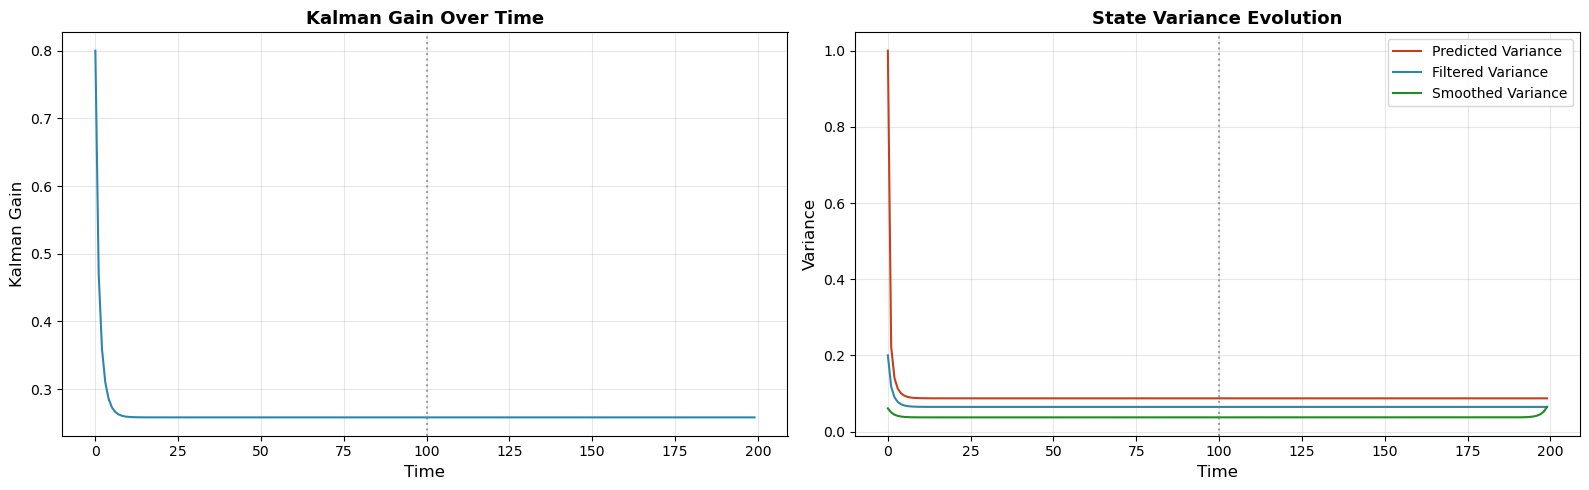

In [48]:
# ============================================
# Kalman Gain & Variance Evolution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Kalman Gain
ax = axes[0]
ax.plot(time, K, '-', color='#2E86AB', linewidth=1.5)
ax.axvline(x=100, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Kalman Gain', fontsize=12)
ax.set_title('Kalman Gain Over Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# State Variance
ax = axes[1]
ax.plot(time, P_pred, '-', color='#C73E1D', linewidth=1.5, label='Predicted Variance')
ax.plot(time, P_filt, '-', color='#2E86AB', linewidth=1.5, label='Filtered Variance')
ax.plot(time, P_smooth, '-', color='#228B22', linewidth=1.5, label='Smoothed Variance')
ax.axvline(x=100, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('State Variance Evolution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Maximum Likelihood Estimation

When parameters ($\\sigma_{\\eta}$, $\\sigma_{\\varepsilon}$) are unknown, we estimate them via **Maximum Likelihood**:

$$\\ell(\\theta) = -\\frac{1}{2} \\sum_{t=1}^{n} \\left[ \\log(2\\pi F_t) + \\frac{v_t^2}{F_t} \\right]$$

We visualize:
1. The **log-likelihood surface** over a grid of parameters
2. The **profile likelihood** for one parameter (maximized over the other)

**Key insight:** The MLE peak should be close to the true parameters. A flat likelihood surface indicates weak identification.


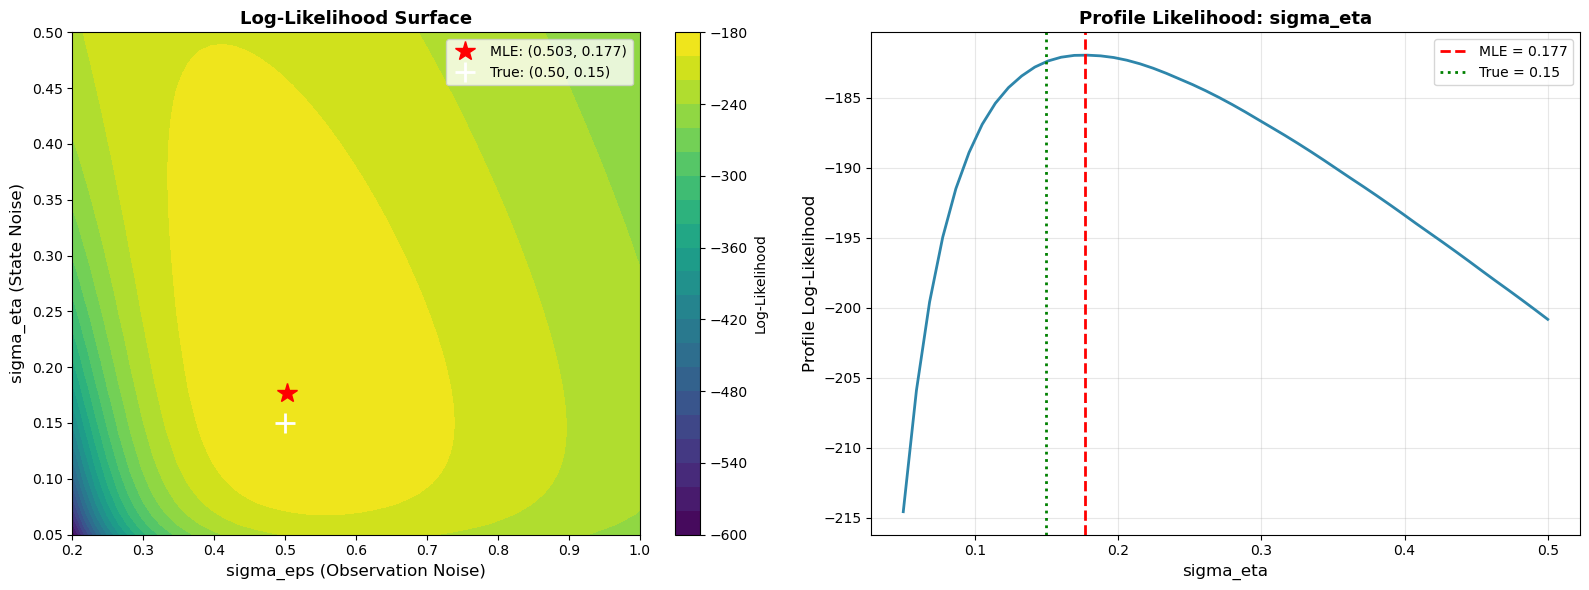

True:  sigma_eta=0.150, sigma_eps=0.500
MLE:   sigma_eta=0.177, sigma_eps=0.503


In [50]:
# ============================================
# Log-Likelihood Surface & MLE
# ============================================


def log_likelihood(params, y, a0, P0):
    sigma_eta, sigma_eps = params
    if sigma_eta <= 0 or sigma_eps <= 0:
        return 1e10
    _, _, _, _, v, F, _ = kalman_filter(y, sigma_eta, sigma_eps, a0, P0)
    ll = -0.5 * np.sum(np.log(2 * np.pi * F) + (v**2 / F))
    return -ll


# Grid search
sigma_eta_grid = np.linspace(0.05, 0.5, 50)
sigma_eps_grid = np.linspace(0.2, 1.0, 50)

ll_surface = np.zeros((len(sigma_eta_grid), len(sigma_eps_grid)))
for i, se in enumerate(sigma_eta_grid):
    for j, sep in enumerate(sigma_eps_grid):
        ll_surface[i, j] = -log_likelihood([se, sep], y, alpha_true[0], 1.0)

# MLE optimization
result = minimize(
    log_likelihood,
    x0=[0.2, 0.6],
    args=(y, alpha_true[0], 1.0),
    method='L-BFGS-B',
    bounds=[(0.01, 2.0), (0.01, 2.0)]
)
mle_eta, mle_eps = result.x

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour plot
ax = axes[0]
X, Y = np.meshgrid(sigma_eps_grid, sigma_eta_grid)
contour = ax.contourf(X, Y, ll_surface, levels=20, cmap='viridis')
ax.plot(mle_eps, mle_eta, 'r*', markersize=15, label=f'MLE: ({mle_eps:.3f}, {mle_eta:.3f})')
ax.plot(sigma_eps_true, sigma_eta_true, 'w+', markersize=15, mew=2,
        label=f'True: ({sigma_eps_true:.2f}, {sigma_eta_true:.2f})')
ax.set_xlabel('sigma_eps (Observation Noise)', fontsize=12)
ax.set_ylabel('sigma_eta (State Noise)', fontsize=12)
ax.set_title('Log-Likelihood Surface', fontsize=13, fontweight='bold')
ax.legend()
plt.colorbar(contour, ax=ax, label='Log-Likelihood')

# Profile likelihood
ax = axes[1]
profile_eta = np.max(ll_surface, axis=1)
ax.plot(sigma_eta_grid, profile_eta, '-', color='#2E86AB', linewidth=2)
ax.axvline(x=mle_eta, color='red', linestyle='--', linewidth=2, label=f'MLE = {mle_eta:.3f}')
ax.axvline(x=sigma_eta_true, color='green', linestyle=':', linewidth=2, label=f'True = {sigma_eta_true:.2f}')
ax.set_xlabel('sigma_eta', fontsize=12)
ax.set_ylabel('Profile Log-Likelihood', fontsize=12)
ax.set_title('Profile Likelihood: sigma_eta', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"True:  sigma_eta={sigma_eta_true:.3f}, sigma_eps={sigma_eps_true:.3f}")
print(f"MLE:   sigma_eta={mle_eta:.3f}, sigma_eps={mle_eps:.3f}")


## State-Space Dashboard

A consolidated view combining all key diagnostics into one figure using `matplotlib.gridspec`.


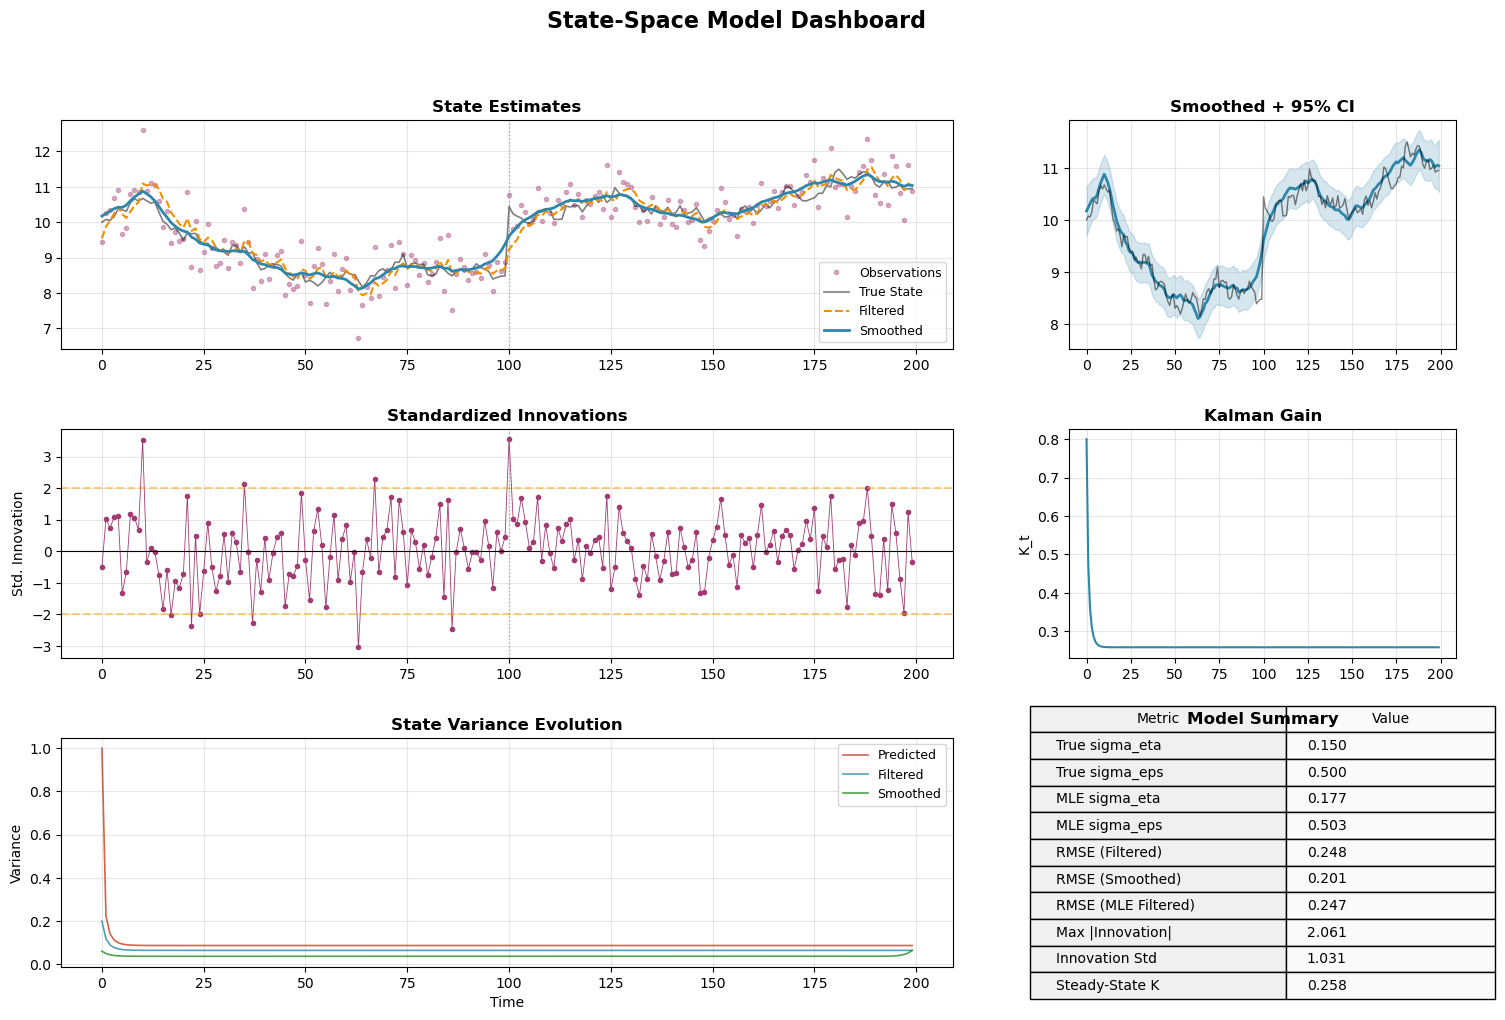

In [51]:
# ============================================
# Comprehensive Dashboard
# ============================================

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# State Estimates
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(time, y, 'o', color='#A23B72', markersize=3, alpha=0.4, label='Observations')
ax1.plot(time, alpha_true, '-', color='black', linewidth=1.2, alpha=0.5, label='True State')
ax1.plot(time, a_filt, '--', color='#F18F01', linewidth=1.5, label='Filtered')
ax1.plot(time, a_smooth, '-', color='#2E86AB', linewidth=2, label='Smoothed')
ax1.axvline(x=100, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax1.set_title('State Estimates', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Smoothed with CI
ax2 = fig.add_subplot(gs[0, 2])
ax2.fill_between(time, ci_lower, ci_upper, color='#2E86AB', alpha=0.2)
ax2.plot(time, a_smooth, '-', color='#2E86AB', linewidth=2)
ax2.plot(time, alpha_true, '-', color='black', linewidth=1, alpha=0.5)
ax2.set_title('Smoothed + 95% CI', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Standardized innovations
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(time, std_innovations, 'o-', color='#A23B72', markersize=3, linewidth=0.6)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.axhline(y=2, color='orange', linestyle='--', alpha=0.5)
ax3.axhline(y=-2, color='orange', linestyle='--', alpha=0.5)
ax3.axvline(x=100, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax3.set_title('Standardized Innovations', fontsize=12, fontweight='bold')
ax3.set_ylabel('Std. Innovation')
ax3.grid(True, alpha=0.3)

# Kalman Gain
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(time, K, '-', color='#2E86AB', linewidth=1.5)
ax4.set_title('Kalman Gain', fontsize=12, fontweight='bold')
ax4.set_ylabel('K_t')
ax4.grid(True, alpha=0.3)

# State Variance
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(time, P_pred, '-', color='#C73E1D', linewidth=1.2, label='Predicted', alpha=0.8)
ax5.plot(time, P_filt, '-', color='#2E86AB', linewidth=1.2, label='Filtered', alpha=0.8)
ax5.plot(time, P_smooth, '-', color='#228B22', linewidth=1.2, label='Smoothed', alpha=0.8)
ax5.set_title('State Variance Evolution', fontsize=12, fontweight='bold')
ax5.set_xlabel('Time')
ax5.set_ylabel('Variance')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Metrics Table
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

# Re-run with MLE params
a_pred_mle, a_filt_mle, _, _, _, _, _ = kalman_filter(y, mle_eta, mle_eps, alpha_true[0], 1.0)
a_smooth_mle, _ = kalman_smoother(a_filt_mle, P_filt, P_pred, mle_eta)

rmse_filt = np.sqrt(np.mean((a_filt - alpha_true)**2))
rmse_smooth = np.sqrt(np.mean((a_smooth - alpha_true)**2))
rmse_filt_mle = np.sqrt(np.mean((a_filt_mle - alpha_true)**2))

metrics = [
    ['True sigma_eta', f'{sigma_eta_true:.3f}'],
    ['True sigma_eps', f'{sigma_eps_true:.3f}'],
    ['MLE sigma_eta', f'{mle_eta:.3f}'],
    ['MLE sigma_eps', f'{mle_eps:.3f}'],
    ['RMSE (Filtered)', f'{rmse_filt:.3f}'],
    ['RMSE (Smoothed)', f'{rmse_smooth:.3f}'],
    ['RMSE (MLE Filtered)', f'{rmse_filt_mle:.3f}'],
    ['Max |Innovation|', f'{np.max(np.abs(v)):.3f}'],
    ['Innovation Std', f'{np.std(std_innovations):.3f}'],
    ['Steady-State K', f'{K[-1]:.3f}'],
]

table = ax6.table(cellText=metrics, colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center', colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for i in range(len(metrics) + 1):
    table[(i, 0)].set_facecolor('#f0f0f0')
    table[(i, 1)].set_facecolor('#fafafa')
ax6.set_title('Model Summary', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('State-Space Model Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.show()


## Summary: How to Interpret Results

| Diagnostic | Good Sign | Bad Sign |
|------------|-----------|----------|
| **Filtered vs Smoothed** | Smoothed closer to true state | Both far off = model misspecified |
| **Innovations** | White noise, mean ~0 | Patterns = autocorrelation |
| **Q-Q Plot** | Points on diagonal | Heavy tails = wrong noise assumption |
| **Kalman Gain** | Converges to steady-state | Oscillates wildly = unstable |
| **Variance** | Filtered < Predicted, Smoothed < Filtered | Increasing variance = diverging |
| **MLE vs True** | Close to true values | Far off = insufficient data or wrong model |

## Extensions

| Model | Use Case |
|-------|----------|
| **Local Linear Trend** | Data with slope changes |
| **Seasonal Component** | Periodic patterns |
| **Dynamic Regression** | Time-varying coefficients |
| **Multivariate Kalman** | Multiple correlated series |
| **Particle Filter** | Non-Gaussian / nonlinear states |


In [52]:
# ============================================
# Final: Key Metrics Summary
# ============================================

print("=" * 60)
print("STATE-SPACE MODEL SUMMARY")
print("=" * 60)
print(f"{'True sigma_eta:':<25} {sigma_eta_true:.4f}")
print(f"{'True sigma_eps:':<25} {sigma_eps_true:.4f}")
print(f"{'MLE sigma_eta:':<25} {mle_eta:.4f}")
print(f"{'MLE sigma_eps:':<25} {mle_eps:.4f}")
print(f"{'RMSE (Filtered):':<25} {rmse_filt:.4f}")
print(f"{'RMSE (Smoothed):':<25} {rmse_smooth:.4f}")
print(f"{'Steady-State Kalman Gain:':<25} {K[-1]:.4f}")
print(f"{'Innovation Std Dev:':<25} {np.std(std_innovations):.4f} (should be ~1.0)")
print(f"{'Max |Standardized Innovation|:':<25} {np.max(np.abs(std_innovations)):.2f}")
print("=" * 60)


STATE-SPACE MODEL SUMMARY
True sigma_eta:           0.1500
True sigma_eps:           0.5000
MLE sigma_eta:            0.1772
MLE sigma_eps:            0.5033
RMSE (Filtered):          0.2478
RMSE (Smoothed):          0.2011
Steady-State Kalman Gain: 0.2584
Innovation Std Dev:       1.0312 (should be ~1.0)
Max |Standardized Innovation|: 3.55
